# How the Model Actually Picks a Word (and Writes a Whole Sentence)

**Notebook 2 of the series.** Notebook 1 showed how a real AI language
model turns an oilfield sentence into a full list of percentages for what
might come next. But a list of percentages isn't an answer by itself —
something still has to pick **one** word. And writing a whole sentence is
really just picking one word, over and over, feeding each choice back in
as new context.

This notebook shows exactly how that happens, using the same real model
and the same kind of realistic oilfield sentences as notebook 1 — nothing
extra, nothing hidden.

Still out of scope here (covered in this project's `advanced/` notebooks):
looking inside the model's internal machinery. This notebook is only about
how a list of percentages turns into one chosen word, and then a whole
sentence.

## What you'll be able to answer by the end

1. What does it mean for an AI to "always play it safe" (this is called
   **greedy decoding**)?
2. Why doesn't an AI tool always pick its own top answer, even when it's
   clearly the most likely one (this is called **sampling**)?
3. What does turning an AI tool's **"temperature"** setting up or down
   actually do, in real numbers?
4. What do the settings **"top-k"** and **"top-p"** mean, and what do they
   actually keep or throw away?
5. How do all these choices combine, one word at a time, to write a whole
   sentence?

A few technical words come up along the way — each one gets a plain-
language explanation and a real example before we use it.


## 1. What problem are we investigating?

Notebook 1 left off with a list of percentages — something like "35% chance
of 'bit', 28% chance of 'one', 7% chance of 'P', ..." A list of percentages
is not yet a decision. Something still has to turn that list into **one**
chosen word:

```
list of percentages -> a decision rule -> one chosen word
```

And applying that same decision rule over and over, feeding each chosen
word back in as new context, is how the model writes a whole sentence:

```
your sentence so far
    -> [ score every possible next word -> pick one -> add it on ]
    -> repeat
    -> a full generated sentence
```

This notebook walks through the two main ways to make that pick (always
play it safe, or roll the dice), the two main knobs used to control the
dice-rolling ("temperature," and two filters called top-k and top-p), and
then puts it all together with a small, fully visible example that
actually writes a few words of oilfield text.


## Installation (run once)

If you already set up the environment for notebook 1, you don't need to do
anything further — this notebook uses the same dependencies. Otherwise,
uncomment and run the cell below once.


In [1]:
# Run this once. After the packages are installed you can leave this commented out.
# %pip install torch transformers accelerate pandas matplotlib numpy
print("If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.")


If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.


## 2. Load the real AI model

Same model, same computer setup as notebook 1 — repeated here so this
notebook runs on its own, without needing notebook 1 to have been run
first. As before, **you don't need to understand the next code cell; just
run it.**


In [2]:
import random
import platform
import sys
from collections import Counter

import numpy as np
import pandas as pd
import torch
import transformers
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PRIMARY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # used only if the primary model fails to load

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

DTYPE = torch.float16 if DEVICE in ("mps", "cuda") else torch.float32

print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Selected device:      {DEVICE}")
print(f"Selected dtype:       {DTYPE}")


Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Selected device:      mps
Selected dtype:       torch.float16


In [3]:
def load_model(model_name: str = PRIMARY_MODEL_NAME):
    '''Load a causal language model and its tokenizer onto the selected device.

    Falls back to FALLBACK_MODEL_NAME if the primary model cannot be loaded,
    and always reports which model actually ended up running.
    '''
    try:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, model_name
    except Exception as exc:  # noqa: BLE001 - report and fall back, don't crash the notebook
        print(f"Could not load '{model_name}' ({exc}). Falling back to '{FALLBACK_MODEL_NAME}'.")
        tok = AutoTokenizer.from_pretrained(FALLBACK_MODEL_NAME)
        mdl = AutoModelForCausalLM.from_pretrained(FALLBACK_MODEL_NAME, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, FALLBACK_MODEL_NAME


tokenizer, model, MODEL_NAME = load_model()
print(f"\nModel actually loaded and used in this notebook: {MODEL_NAME}")
print(f"Vocabulary size: {model.config.vocab_size:,} tokens")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Model actually loaded and used in this notebook: Qwen/Qwen2.5-1.5B-Instruct
Vocabulary size: 151,936 tokens


## 3. Reusing what notebook 1 already built

These four functions were built and explained step by step in notebook 1:
breaking a sentence into tokens, asking the model to score every possible
next word, turning those scores into percentages, and measuring how
"spread out" the model's answer is. We won't re-explain them here — we
just reuse them so this notebook can focus entirely on what happens next.


In [4]:
def tokenize_prompt(prompt: str):
    '''Tokenize a prompt and return (encoded inputs, input_ids tensor, decoded token strings).'''
    encoded = tokenizer(prompt, return_tensors="pt")
    input_ids = encoded["input_ids"][0]
    decoded_tokens = [tokenizer.decode([tid]) for tid in input_ids]
    return encoded, input_ids, decoded_tokens


def get_next_token_distribution(prompt: str):
    '''Run `prompt` through the model and return (input_ids, logits, probabilities) for the next token.'''
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(**enc)
    logits_vec = out.logits[0, -1, :]
    probs_vec = torch.softmax(logits_vec, dim=-1)
    return enc["input_ids"][0], logits_vec, probs_vec


def get_top_tokens(prompt: str, n: int = 15) -> pd.DataFrame:
    '''Return a DataFrame of the top-n next-token candidates for `prompt`, straight from the model.'''
    _, logits_vec, probs_vec = get_next_token_distribution(prompt)
    top_probs, top_ids = torch.topk(probs_vec, n)

    rows = []
    for rank, (tid, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
        rows.append({
            "rank": rank,
            "token_id": tid,
            "decoded_token": repr(tokenizer.decode([tid])),
            "logit": logits_vec[tid].item(),
            "probability": prob,
            "probability_percent": f"{prob * 100:.2f}%",
        })
    return pd.DataFrame(rows)


def calculate_entropy(probabilities: torch.Tensor) -> float:
    '''Shannon entropy (natural log, in nats) of a probability distribution tensor.'''
    # Cast to float32 before clamping: in float16 (used on MPS/CUDA), tiny
    # probabilities underflow to exactly 0 at this clamp threshold, and
    # 0 * log(0) produces NaN.
    p = probabilities.float().clamp_min(1e-12)
    return float(-(p * p.log()).sum().item())


def show(df: pd.DataFrame):
    '''Display a table without pandas' default row-number column on the left, which isn't real data.'''
    display(df.style.hide(axis="index"))


## 4. Our starting sentence

Same sentence as notebook 1, so results are directly comparable. We
compute its real list of percentages once, up front — every experiment
below reuses this same real result rather than recomputing something
different each time.


In [5]:
PROMPT = "The crew pulled out of hole with the worn PDC bit and prepared to run a new"

_, baseline_logits, baseline_probs = get_next_token_distribution(PROMPT)
baseline_top_tokens = get_top_tokens(PROMPT, n=15)

print(repr(PROMPT))
show(baseline_top_tokens)


'The crew pulled out of hole with the worn PDC bit and prepared to run a new'


rank,token_id,decoded_token,logit,probability,probability_percent
1,2699,' bit',19.906250,0.335205,33.52%
2,825,' one',19.718750,0.277832,27.78%
3,393,' P',18.406250,0.074829,7.48%
4,220,' ',17.312500,0.025055,2.51%
5,30546,' drill',17.078125,0.019821,1.98%
6,5392,' tool',16.765625,0.014503,1.45%
7,22205,' diamond',16.656250,0.013000,1.30%
8,11,"','",16.593750,0.012215,1.22%
9,1632,' well',15.554688,0.004322,0.43%
10,738,' set',15.531250,0.004219,0.42%


## 5. Always play it safe: greedy decoding

**Greedy decoding** simply picks whichever word has the single highest
percentage — always. Give it the same sentence twice, and it gives you the
exact same next word both times. (The technical name for "pick the
highest one" is `argmax` — you may see that word elsewhere, but "always
pick the top answer" is all it means.)

Real scores and real percentages always agree on which word ranks first —
that's a property of how percentages are built from the raw scores in
notebook 1. We check that below with the real numbers, rather than just
assuming it.


In [6]:
def greedy_decode(probabilities: torch.Tensor) -> int:
    '''Return the token ID with the highest probability.'''
    return int(torch.argmax(probabilities).item())


greedy_token_id = greedy_decode(baseline_probs)
greedy_token_id_from_logits = int(torch.argmax(baseline_logits).item())

print(f"Greedy token from probabilities: {greedy_token_id} -> {tokenizer.decode([greedy_token_id])!r}")
print(f"Greedy token from raw logits:    {greedy_token_id_from_logits} -> {tokenizer.decode([greedy_token_id_from_logits])!r}")
assert greedy_token_id == greedy_token_id_from_logits, "argmax over probabilities and over logits should always agree."
assert greedy_token_id == baseline_top_tokens.iloc[0]["token_id"], "Greedy decoding should match rank 1 in the top-tokens table."
print("Sanity checks passed: greedy decoding matches both argmax(logits) and rank 1 of the top-tokens table.")


Greedy token from probabilities: 2699 -> ' bit'
Greedy token from raw logits:    2699 -> ' bit'
Sanity checks passed: greedy decoding matches both argmax(logits) and rank 1 of the top-tokens table.


## 6. Rolling the dice: sampling

**Sampling** doesn't always take the top answer — it rolls a weighted die
instead, where each word's percentage is its odds of winning that roll. A
word with a 33% chance will tend to come up about a third of the time —
not every single time.

> **If you're comfortable reading code:** we use `torch.multinomial`,
> PyTorch's weighted-random-draw function, seeded so the "random" draw is
> reproducible on your machine. If you're not, that's fine — the plain
> description above is all that matters.


In [7]:
def sample_next_token(probabilities: torch.Tensor, seed: int | None = None) -> int:
    '''Draw one token ID at random, weighted by `probabilities`.'''
    probs_cpu = probabilities.detach().to("cpu", dtype=torch.float32)
    generator = torch.Generator(device="cpu")
    if seed is not None:
        generator.manual_seed(seed)
    else:
        generator.seed()
    return int(torch.multinomial(probs_cpu, num_samples=1, generator=generator).item())


sampled_id = sample_next_token(baseline_probs, seed=0)
print(f"One sample (seed=0): {sampled_id} -> {tokenizer.decode([sampled_id])!r}")
print(f"Greedy token, for comparison: {greedy_token_id} -> {tokenizer.decode([greedy_token_id])!r}")


One sample (seed=0): 1863 -> ' Z'
Greedy token, for comparison: 2699 -> ' bit'


### Does the top answer always win when you roll the dice?

We roll this weighted die 500 separate times on the exact same sentence,
and count how often each word actually comes up. If the dice-rolling is
working correctly, each word should come up close to its real percentage
of the time — but "close" doesn't mean "the top word wins every single
roll."


In [8]:
N_DRAWS = 500
sampled_ids = [sample_next_token(baseline_probs, seed=i) for i in range(N_DRAWS)]
sample_counts = Counter(sampled_ids)

top8_by_true_prob = baseline_top_tokens.head(8).copy()
top8_by_true_prob["empirical_count"] = [sample_counts.get(tid, 0) for tid in top8_by_true_prob["token_id"]]
top8_by_true_prob["empirical_frequency_percent"] = top8_by_true_prob["empirical_count"] / N_DRAWS * 100

print(f"Unique distinct tokens drawn across {N_DRAWS} samples: {len(sample_counts)}")
show(top8_by_true_prob[["rank", "decoded_token", "probability_percent", "empirical_count", "empirical_frequency_percent"]])


Unique distinct tokens drawn across 500 samples: 118


rank,decoded_token,probability_percent,empirical_count,empirical_frequency_percent
1,' bit',33.52%,174,34.800000
2,' one',27.78%,129,25.800000
3,' P',7.48%,32,6.400000
4,' ',2.51%,6,1.200000
5,' drill',1.98%,8,1.600000
6,' tool',1.45%,4,0.800000
7,' diamond',1.30%,7,1.400000
8,"','",1.22%,3,0.600000


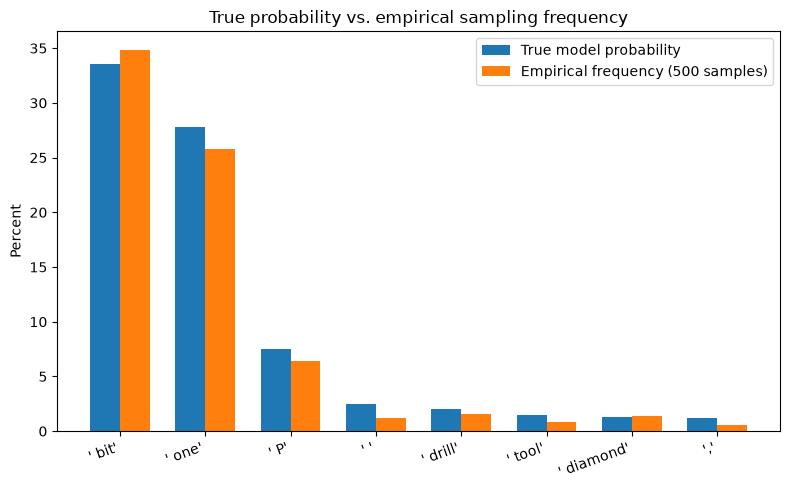

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(top8_by_true_prob))
width = 0.35
true_pct = top8_by_true_prob["probability"] * 100
empirical_pct = top8_by_true_prob["empirical_frequency_percent"]

ax.bar([i - width / 2 for i in x], true_pct, width, label="True model probability")
ax.bar([i + width / 2 for i in x], empirical_pct, width, label=f"Empirical frequency ({N_DRAWS} samples)")
ax.set_xticks(list(x))
ax.set_xticklabels(top8_by_true_prob["decoded_token"], rotation=20, ha="right")
ax.set_ylabel("Percent")
ax.set_title("True probability vs. empirical sampling frequency")
ax.legend()
fig.tight_layout()
plt.show()


**What this shows:** the two bars for each word should be close but
not identical — that gap is just normal randomness over a limited number
of rolls, not a mistake. It's also a good check on our own dice-rolling
code: if the actual roll counts didn't roughly track the real percentages
at all, that would point to a bug, not an interesting finding.


## 7. Temperature: making the dice fairer or more lopsided

You've probably seen a "temperature" setting in an AI chat tool. Here's
exactly what it does to real numbers.

**Temperature** reshapes the model's raw scores before they're turned into
percentages, then rolls the same weighted die on the reshaped numbers:

- **Lower temperature (e.g. 0.3)** makes the die *more* lopsided — the top
  few words become even more likely to be picked.
- **Higher temperature (e.g. 1.5)** makes the die *more* fair — lower-ranked
  words get a noticeably better shot.
- **Temperature does not retrain the model or change its opinions.** We
  reuse the model's exact same raw scores from Section 4 for every
  temperature below — only how those scores get reshaped changes.

> **For the curious:** temperature works by dividing every raw score by a
> number (`T`) before turning them into percentages
> ($P_i = e^{z_i/T} / \sum_j e^{z_j/T}$), but you don't need the formula —
> "lower number = more lopsided, higher number = more fair" is enough to
> follow along.


In [10]:
def apply_temperature(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    '''Return a probability distribution: softmax(logits / temperature). Uses the same logits every time.'''
    scaled_logits = logits.float() / temperature
    return torch.softmax(scaled_logits, dim=-1)


TEMPERATURES = [0.3, 0.7, 1.0, 1.5]
temperature_probs = {T: apply_temperature(baseline_logits, T) for T in TEMPERATURES}

for T in TEMPERATURES:
    top_probs, top_ids = torch.topk(temperature_probs[T], 5)
    print(f"--- Temperature = {T} ---")
    for tid, p in zip(top_ids.tolist(), top_probs.tolist()):
        print(f"  {tokenizer.decode([tid])!r:15s} {p * 100:6.2f}%")


--- Temperature = 0.3 ---
  ' bit'           64.84%
  ' one'           34.70%
  ' P'              0.44%
  ' '               0.01%
  ' drill'          0.01%
--- Temperature = 0.7 ---
  ' bit'           50.00%
  ' one'           38.25%
  ' P'              5.87%
  ' '               1.23%
  ' drill'          0.88%
--- Temperature = 1.0 ---
  ' bit'           33.53%
  ' one'           27.79%
  ' P'              7.48%
  ' '               2.51%
  ' drill'          1.98%
--- Temperature = 1.5 ---
  ' bit'            7.61%
  ' one'            6.71%
  ' P'              2.80%
  ' '               1.35%
  ' drill'          1.15%


In [11]:
reference_token_id = greedy_token_id  # the T=1.0 top token, e.g. ' bit'
reference_token_text = tokenizer.decode([reference_token_id])

temp_summary = pd.DataFrame({
    "temperature": TEMPERATURES,
    f"probability_of_{reference_token_text.strip()!r}_percent": [
        temperature_probs[T][reference_token_id].item() * 100 for T in TEMPERATURES
    ],
    "entropy_nats": [calculate_entropy(temperature_probs[T]) for T in TEMPERATURES],
})
show(temp_summary)


temperature,probability_of_'bit'_percent,entropy_nats
0.300000,64.837259,0.674001
0.700000,50.002903,1.257959
1.000000,33.525372,3.113424
1.500000,7.607074,7.650571


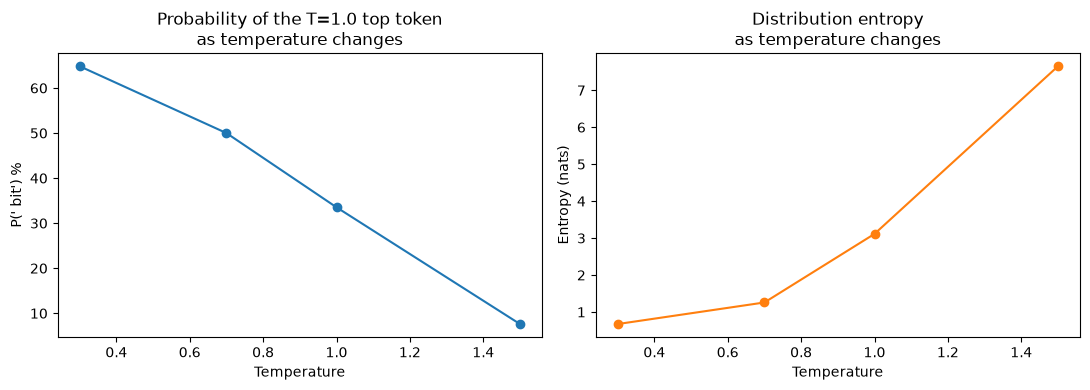

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(temp_summary["temperature"], temp_summary.iloc[:, 1], marker="o")
ax1.set_xlabel("Temperature")
ax1.set_ylabel(f"P({reference_token_text!r}) %")
ax1.set_title("Probability of the T=1.0 top token\nas temperature changes")

ax2.plot(temp_summary["temperature"], temp_summary["entropy_nats"], marker="o", color="tab:orange")
ax2.set_xlabel("Temperature")
ax2.set_ylabel("Entropy (nats)")
ax2.set_title("Distribution entropy\nas temperature changes")

fig.tight_layout()
plt.show()


**What this shows:** as temperature rises, the top word's share
(left chart) should fall and the uncertainty score (right chart, "entropy"
— see notebook 1, Section 10) should rise — both computed from the same
underlying scores. This is the model's original opinions being reshaped,
not the model "changing its mind."


## 8. Does a fairer die actually produce more variety?

The uncertainty score in Section 7 is a theoretical property of the
percentages. Let's check it against what actually happens when you roll
the dice: 500 rolls at a lopsided setting (temperature 0.3) and 500 at a
fair setting (temperature 1.5), on the same sentence, counting how many
*different* words actually come up at each setting.


In [13]:
diversity_rows = []
for T in [0.3, 1.5]:
    probs_T = temperature_probs[T]
    draws = [sample_next_token(probs_T, seed=i) for i in range(N_DRAWS)]
    diversity_rows.append({
        "temperature": T,
        "unique_tokens_sampled": len(set(draws)),
        "entropy_nats": calculate_entropy(probs_T),
    })

diversity_summary = pd.DataFrame(diversity_rows)
show(diversity_summary)


temperature,unique_tokens_sampled,entropy_nats
0.300000,3,0.674001
1.500000,366,7.650571


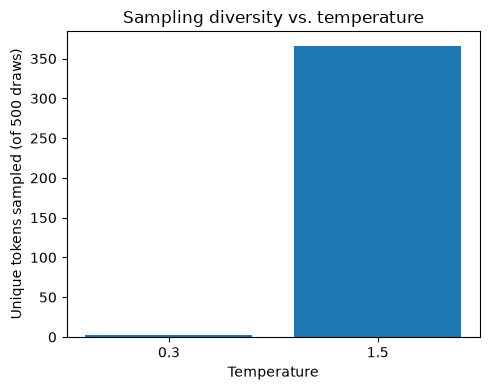

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(diversity_summary["temperature"].astype(str), diversity_summary["unique_tokens_sampled"])
ax.set_xlabel("Temperature")
ax.set_ylabel(f"Unique tokens sampled (of {N_DRAWS} draws)")
ax.set_title("Sampling diversity vs. temperature")
fig.tight_layout()
plt.show()


**What this shows:** more different words coming up at the higher
temperature is a direct, real consequence of the fairer die measured in
Section 7 — not a separate claim that the model got "more creative."


## 9. Two more settings: "top-k" and "top-p"

Rather than rolling the die across every single word in the vocabulary,
these two settings first throw away most of the options, keeping only a
chosen few, then reroll the percentages among just the survivors so they
still add up to 100%:

- **Top-k**: keep only the `k` highest-percentage words (e.g. top-k = 5
  keeps just the 5 best options).
- **Top-p** (also called "nucleus sampling"): keep the smallest group of
  words whose percentages add up to at least `p` (e.g. top-p = 0.9 keeps
  just enough top words to reach 90%).

Both are applied here to the real starting sentence from Section 4.


In [15]:
def top_k_filter(probabilities: torch.Tensor, k: int):
    '''Return (surviving token IDs, their renormalized probabilities) for the top-k tokens.'''
    probs = probabilities.float()
    top_probs, top_ids = torch.topk(probs, k)
    renormalized = top_probs / top_probs.sum()
    return top_ids, renormalized


def top_p_filter(probabilities: torch.Tensor, p: float):
    '''Return (surviving token IDs, their renormalized probabilities) for the smallest set reaching cumulative probability p.'''
    probs = probabilities.float()
    sorted_probs, sorted_ids = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)
    n_keep = int((cumulative < p).sum().item()) + 1  # include the token that crosses the threshold
    n_keep = min(n_keep, sorted_probs.shape[0])
    kept_ids = sorted_ids[:n_keep]
    kept_probs = sorted_probs[:n_keep]
    renormalized = kept_probs / kept_probs.sum()
    return kept_ids, renormalized


topk_ids, topk_probs = top_k_filter(baseline_probs, k=5)
topp_ids, topp_probs = top_p_filter(baseline_probs, p=0.9)

topk_table = pd.DataFrame({
    "decoded_token": [repr(tokenizer.decode([tid])) for tid in topk_ids.tolist()],
    "original_probability_percent": [baseline_probs[tid].item() * 100 for tid in topk_ids.tolist()],
    "renormalized_probability_percent": (topk_probs * 100).tolist(),
})
print(f"Top-k = 5: {len(topk_ids)} tokens survive.")
show(topk_table)

topp_table = pd.DataFrame({
    "decoded_token": [repr(tokenizer.decode([tid])) for tid in topp_ids.tolist()],
    "original_probability_percent": [baseline_probs[tid].item() * 100 for tid in topp_ids.tolist()],
    "renormalized_probability_percent": (topp_probs * 100).tolist(),
})
print(f"\nTop-p = 0.9: {len(topp_ids)} tokens survive.")
show(topp_table)


Top-k = 5: 5 tokens survive.


decoded_token,original_probability_percent,renormalized_probability_percent
' bit',33.520508,45.746651
' one',27.783203,37.916744
' P',7.482910,10.212198
' ',2.505493,3.419338
' drill',1.982117,2.705066



Top-p = 0.9: 133 tokens survive.


decoded_token,original_probability_percent,renormalized_probability_percent
' bit',33.520508,37.235683
' one',27.783203,30.862495
' P',7.482910,8.312263
' ',2.505493,2.783184
' drill',1.982117,2.201800
' tool',1.450348,1.611094
' diamond',1.300049,1.444137
"','",1.221466,1.356845
' well',0.432205,0.480108
' set',0.421906,0.468667


**What this shows:** how many words survive top-p = 0.9 depends
entirely on how spread out the model's answer is for this sentence — a
more uncertain answer needs more words to add up to 90% than a
confident, concentrated one. Compare the survivor count above to
Section 4's uncertainty score; that connection is real, computed from the
actual numbers, not just asserted.


## 10. Putting it all together: writing more than one word

Everything so far has been a single decision. Writing text is just this
same loop, repeated: score every possible next word for the sentence so
far, pick one (using whichever method we're demonstrating), add it onto
the sentence, and do it all again from the new, longer sentence.

The function below does exactly that, one plain step at a time, so every
part of the process stays visible. (For anyone curious: real production AI
tools use a faster shortcut here so they don't have to redo the entire
first part of the sentence at every step — we skip that shortcut on
purpose, to keep every step visible, which is fine for the dozen words we
generate here.)


In [16]:
def generate_tokens(prompt: str, n_new_tokens: int, strategy: str = "greedy",
                     temperature: float = 1.0, seed: int | None = None):
    '''Manually repeat single-step next-token prediction n_new_tokens times.

    strategy="greedy" always takes argmax (temperature has no effect on it,
    since temperature scaling preserves the ordering of logits).
    strategy="sample" draws from softmax(logits / temperature).
    '''
    text = prompt
    new_token_reprs = []
    for step in range(n_new_tokens):
        _, logits_vec, probs_vec = get_next_token_distribution(text)
        if strategy == "greedy":
            next_id = int(torch.argmax(logits_vec).item())
        elif strategy == "sample":
            probs_for_sampling = apply_temperature(logits_vec, temperature)
            step_seed = None if seed is None else seed + step
            next_id = sample_next_token(probs_for_sampling, seed=step_seed)
        else:
            raise ValueError(f"Unknown strategy {strategy!r}: use 'greedy' or 'sample'.")
        next_token_text = tokenizer.decode([next_id])
        text += next_token_text
        new_token_reprs.append(repr(next_token_text))
    return text, new_token_reprs


greedy_text, greedy_new_tokens = generate_tokens(PROMPT, n_new_tokens=12, strategy="greedy")
print("GREEDY completion:")
print(greedy_text)
print("\nNew tokens generated, in order:")
print(greedy_new_tokens)


GREEDY completion:
The crew pulled out of hole with the worn PDC bit and prepared to run a new bit. The crew was working on a 100

New tokens generated, in order:
["' bit'", "'.'", "' The'", "' crew'", "' was'", "' working'", "' on'", "' a'", "' '", "'1'", "'0'", "'0'"]


In [17]:
sampled_text, sampled_new_tokens = generate_tokens(
    PROMPT, n_new_tokens=12, strategy="sample", temperature=1.0, seed=42,
)
print("SAMPLED completion (temperature=1.0, seed=42):")
print(sampled_text)
print("\nNew tokens generated, in order:")
print(sampled_new_tokens)


SAMPLED completion (temperature=1.0, seed=42):
The crew pulled out of hole with the worn PDC bit and prepared to run a new PDC bit with adequate filler. However, the casing pul

New tokens generated, in order:
["' P'", "'DC'", "' bit'", "' with'", "' adequate'", "' filler'", "'.'", "' However'", "','", "' the'", "' casing'", "' pul'"]


In [18]:
low_temp_text, _ = generate_tokens(PROMPT, n_new_tokens=12, strategy="sample", temperature=0.3, seed=42)
high_temp_text, _ = generate_tokens(PROMPT, n_new_tokens=12, strategy="sample", temperature=1.5, seed=42)

print("Temperature 0.3:")
print(low_temp_text)
print("\nTemperature 1.5:")
print(high_temp_text)


Temperature 0.3:
The crew pulled out of hole with the worn PDC bit and prepared to run a new bit. The crew was using a 2000

Temperature 1.5:
The crew pulled out of hole with the worn PDC bit and prepared to run a new Peprotec KunSkycretetank behind the roller casing you


**What this shows:** the greedy completion is fully predictable —
run it again and you get the exact same text, every time. The dice-rolled
completions are reproducible here only *because we fixed a starting point
for the randomness (a "seed")*; without one, they'd come out differently
each time you ran the cell. Read the actual sentences above rather than
assuming which one "sounds more natural" — that's a separate, human
judgment call, not something the model's percentages tell us directly.


## 11. What these settings do — and don't do

We can honestly say, because we computed it directly above:

- always playing it safe (greedy) always picks the single highest-
  percentage word
- rolling the dice (sampling) picks a word at random, weighted by the
  model's real percentages
- temperature reshapes those percentages before the roll, the same way
  regardless of what the sentence is even about
- top-k and top-p decide *which* words are even eligible to be rolled for

We should **not** say:

- "a higher temperature makes the AI more creative or smarter" — it makes
  the dice *fairer*; whether the resulting text reads as "creative" is a
  human judgment about the words that came out, not something the setting
  itself measures
- "the model is confident" as another way of saying "this word had a high
  percentage" — a percentage is a property of one single decision, not a
  window into the model's internal certainty in a human sense
- that any of these settings change what the model actually "knows" —
  every experiment above reused the exact same underlying scores from
  Section 4; only the rule used to pick a word from them changed

Choosing a decoding setting happens *after* the model has already finished
scoring every possible word. It changes which word gets picked. It does
not change the model itself.


## 12. Key lessons

```
your sentence so far
  |
  v
The model scores every possible next word (notebook 1)
  |
  v
Decision rule
  (always play it safe / roll the dice, optionally with
   temperature, top-k, or top-p)
  |
  v
One chosen word
  |
  v
add it to the sentence, repeat -> a full generated sentence
```

1. Always playing it safe (greedy decoding) picks the single highest-
   percentage word every time — predictable and repeatable.
2. Rolling the dice (sampling) draws from the real percentages — the top
   word is favored, but never guaranteed.
3. Over many rolls, how often each word actually comes up tracks its real
   percentage — we verified that directly, rather than assuming it.
4. Temperature reshapes the same underlying scores; it doesn't retrain or
   otherwise change the model.
5. A lower temperature means a more lopsided die (less variety in repeated
   rolls); a higher temperature means a fairer die (more variety).
6. Top-k and top-p decide which words are even eligible to be rolled for,
   and how many survive depends on how spread out the real answer is.
7. Writing a whole sentence is this same one-word decision, looped —
   nothing more mysterious than notebook 1's single step, repeated.
8. None of these settings change what the model "knows" — only how one
   word gets picked from what it already scored.


## 13. Try your own oilfield sentence

Change the values below, then run the cell. It reuses the same
sentence-writing steps from Section 10 with the settings you choose.


In [19]:
user_prompt = "The crew ran in hole with the completion assembly and began to"  # <-- change this line
user_strategy = "sample"      # "greedy" or "sample"
user_temperature = 0.8        # only used when user_strategy == "sample"
user_n_new_tokens = 12
user_seed = 7                 # only used when user_strategy == "sample"; set to None for a fresh random draw each run

user_text, user_new_tokens = generate_tokens(
    user_prompt,
    n_new_tokens=user_n_new_tokens,
    strategy=user_strategy,
    temperature=user_temperature,
    seed=user_seed,
)

print(f"Strategy: {user_strategy}" + (f", temperature={user_temperature}" if user_strategy == "sample" else ""))
print(f"\nCompletion:\n{user_text}")
print(f"\nNew tokens generated, in order:\n{user_new_tokens}")

print("\nFirst-step top-10 candidates (before any decoding choice was applied):")
show(get_top_tokens(user_prompt, n=10))


Strategy: sample, temperature=0.8

Completion:
The crew ran in hole with the completion assembly and began to complete the ____ step.
A. 5
B.

New tokens generated, in order:
["' complete'", "' the'", "' ____'", "' step'", "'.\\n'", "'A'", "'.'", "' '", "'5'", "'\\n'", "'B'", "'.'"]

First-step top-10 candidates (before any decoding choice was applied):


rank,token_id,decoded_token,logit,probability,probability_percent
1,4582,' install',18.062500,0.056396,5.64%
2,1598,' run',17.796875,0.043243,4.32%
3,41740,' assemble',17.609375,0.035858,3.59%
4,4828,' raise',17.328125,0.027054,2.71%
5,2795,' load',17.265625,0.025421,2.54%
6,11893,' lift',16.968750,0.018890,1.89%
7,6815,' pull',16.937500,0.018311,1.83%
8,4057,' remove',16.906250,0.017746,1.77%
9,3271,' move',16.812500,0.016159,1.62%
10,975,' work',16.718750,0.014709,1.47%


## 14. Optional exercises

1. In Section 13, switch `user_strategy` to `"greedy"` and compare the
   result to the dice-rolled one.
2. Try `user_temperature = 0.1` and `user_temperature = 2.0`. How different
   are the results? How does that connect to the uncertainty scores in
   Section 7?
3. Re-run Section 6's 500-roll experiment (`N_DRAWS`) with a different
   sentence from notebook 1's context experiments (e.g. one of the POOH
   sentences). Does the top word's roll count still track its true
   percentage?
4. Change `top_p_filter`'s `p` argument to `0.5` and to `0.99`. How many
   words survive in each case?
5. Set `user_seed = None` in Section 13 and run the cell twice in a row.
   Confirm the result differs between runs — then set a fixed seed again
   and confirm it becomes repeatable.


## 15. Technical appendix (optional — skip if you like)

Nothing in this section is needed to understand the rest of the notebook.

**Model and environment actually used in this run** (printed live, not
hard-coded):


In [20]:
print(f"Model:                {MODEL_NAME}")
print(f"Device:               {DEVICE}")
print(f"Dtype:                {DTYPE}")
print(f"Vocabulary size:      {model.config.vocab_size:,}")
print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Random seed:          {SEED}")


Model:                Qwen/Qwen2.5-1.5B-Instruct
Device:               mps
Dtype:                torch.float16
Vocabulary size:      151,936
Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Random seed:          42


**Efficiency note.** `generate_tokens` in Section 10 recomputes the
model's scoring over the whole growing sentence at every new word, so
every intermediate step stays fully visible — which is the point of this
notebook. Real production AI tools instead cache earlier work (a
technique called a "KV cache") so each new word only needs a small
incremental step. For the dozen words generated here on a small model, the
difference isn't noticeable on a laptop; for writing much longer text, it
would be.

**Reproducibility.** All the dice-rolling above uses an explicitly seeded
random-number generator, so every result in this notebook comes out the
same way on your own machine. Setting `seed=None` anywhere restores true
randomness — a different result every time you run that cell.
